In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib


In [18]:
'''
create ensemble mean
'''

scen = 'all'

if scen == 'all':
    file_name_setup = ['ua_Amon_d4PDF_HPB_m','_195101-201112.nc']

ds_list = []
for ens_mem in range(1,101):
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    print(number)
    
    ds = xr.open_dataset('/home/stoneda/data/C20C/d4PDF/MRI-AGCM3-2H/HPB/est1/v1-0/mon/atmos/ua/m'+number+'/'+file_name_setup[0]+number+file_name_setup[1])

    ds_list.append(ds)
    ds.close()
    
ens_mean = sum(ds_list)/len(ds_list)
    


In [105]:
ens_mean_1 = xr.open_dataset('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/UA/HPB/ens_mean.nc')
ens_mean_2 = xr.open_dataset('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/UA/HPB/ua_Amon_d4PDF_HPB_ensMEAN_195101-201112.nc')

In [111]:
ens_mean_1.ua.sel(lev=850, lon=245, lat= 0)

<xarray.DataArray 'ua' (time: 732)>
array([-7.592597, -6.004103, -5.811991, ..., -5.478003, -8.757618, -9.164926],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1951-01-01T12:00:00 ... 2011-12-01T12:00:00
    lon      float64 245.0
    lat      float64 0.0
    lev      float64 850.0

In [110]:
ens_mean_2.ua.sel(lev=850, lon=245, lat= 0)

<xarray.DataArray 'ua' (time: 732)>
array([-7.592597, -6.004103, -5.811991, ..., -5.478003, -8.757618, -9.164925],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1951-01-01T12:00:00 ... 2011-12-01T12:00:00
    lon      float64 245.0
    lat      float64 0.0
    lev      float64 850.0
Attributes:
    long_name:  ZONAL VELOCITY                                               ...

In [20]:
ens_mean.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/UA/HPB/ens_mean.nc')

In [67]:
era5 = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/ERA_u_wind.nc')
era5_seasonal = era5.u.resample(time='QS-DEC').mean()

#d4PDF_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/UA/HPB/ens_mean.nc')
#d4PDF_seasonal = ds.ua.resample(time='QS-DEC').mean()

In [68]:
era5_seasonal

<xarray.DataArray 'u' (time: 166, expver: 2, level: 37, latitude: 361, longitude: 161)>
array([[[[[-1.82483425e+01, -1.82174301e+01, -1.81828785e+01, ...,
           -1.50297661e+01, -1.50479498e+01, -1.50643158e+01],
          [-1.87229462e+01, -1.86938515e+01, -1.86629410e+01, ...,
           -1.56607504e+01, -1.56753016e+01, -1.56934834e+01],
          [-1.91957321e+01, -1.91666374e+01, -1.91393623e+01, ...,
           -1.63008308e+01, -1.63153763e+01, -1.63335648e+01],
          ...,
          [-1.40665054e-01, -1.40665054e-01, -1.40665054e-01, ...,
           -1.09752655e-01, -1.11571312e-01, -1.11571312e-01],
          [-6.10351562e-03, -6.10351562e-03, -4.28485870e-03, ...,
           -1.51948929e-02, -1.70135498e-02, -1.70135498e-02],
          [-6.47544861e-04, -6.47544861e-04, -6.47544861e-04, ...,
           -6.47544861e-04, -6.47544861e-04, -6.47544861e-04]],

         [[-1.27185726e+01, -1.27167540e+01, -1.27149372e+01, ...,
           -1.31531706e+01, -1.31513529e+01, -1.31458979e+01],
          [-1.34604816e+01, -1.34623003e+01, -1.34623003e+01, ...,
           -1.37968864e+01, -1.37950687e+01, -1.37896137e+01],
          [-1.42060289e+01, -1.42042093e+01, -1.42078466e+01, ...,
           -1.44424210e+01, -1.44406033e+01, -1.44387836e+01],
...
           -6.17088318e-01, -6.27998352e-01, -6.42545700e-01],
          [ 1.53226662e+00,  1.52499390e+00,  1.51771927e+00, ...,
           -1.11570358e-01, -1.26117706e-01, -1.37027740e-01],
          [ 1.17111206e-03,  1.17111206e-03,  1.17111206e-03, ...,
            1.17111206e-03,  1.17111206e-03,  1.17111206e-03]],

         [[-2.85372543e+00, -2.93373489e+00, -3.00283623e+00, ...,
           -6.86149025e+00, -6.86876488e+00, -6.86876488e+00],
          [-2.71916389e+00, -2.81372070e+00, -2.90464020e+00, ...,
           -6.90876961e+00, -6.90513039e+00, -6.90149498e+00],
          [-2.58460236e+00, -2.68279648e+00, -2.78826332e+00, ...,
           -6.95604897e+00, -6.95240974e+00, -6.94513512e+00],
          ...,
          [ 1.21586418e+00,  1.20495415e+00,  1.19768143e+00, ...,
           -3.84330750e-01, -3.91605377e-01, -4.02515411e-01],
          [ 1.64864540e+00,  1.63773537e+00,  1.63046074e+00, ...,
            2.29911804e-02,  1.20811462e-02,  1.17111206e-03],
          [ 1.17111206e-03,  1.17111206e-03,  1.17111206e-03, ...,
            1.17111206e-03,  1.17111206e-03,  1.17111206e-03]]]]],
      dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 1978-12-01 1979-03-01 ... 2020-03-01
  * longitude  (longitude) float32 160.0 160.2 160.5 160.8 ... 199.5 199.8 200.0
  * latitude   (latitude) float32 0.0 -0.25 -0.5 -0.75 ... -89.5 -89.75 -90.0
  * level      (level) int32 1 2 3 5 7 10 20 30 ... 850 875 900 925 950 975 1000
  * expver     (expver) int32 1 5

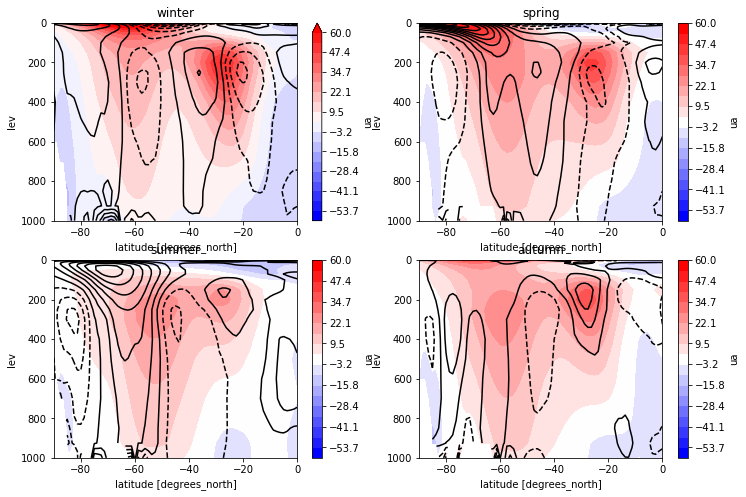

In [100]:
fig,axs = plt.subplots(2,2, figsize=(12,8))
axs = axs.flatten()

for i,s in enumerate([6,9,12,3]):
    
    da = d4PDF_seasonal.sel(time=d4PDF_seasonal.time.dt.month.isin([s]))
    #da = da.reindex(lev=da.lev[::-1])
    
    past = da.sel(time=slice('1979','1986'),lon=slice(160,200),lat=slice(-90,0)).mean(['lon','time'])
    present = da.sel(time=slice('2002','2011'),lon=slice(160,200),lat=slice(-90,0)).mean(['lon','time'])
    diff = present - past
    
    past.plot.contourf(ax=axs[i],vmin=-60,vmax=60,cmap='bwr',levels=20)
    diff.plot.contour(ax=axs[i],levels=20,vmin=-10,vmax=10,colors='black')#vmin=-7,vmax=7,levels=20)
    axs[i].set_ylim(axs[i].get_ylim()[::-1])
    
    axs[i].set_title(season_a[s])
    
plt.savefig('/nesi/project/niwa00015/queenle/figures/wind/d4PDF.png',dpi=300)

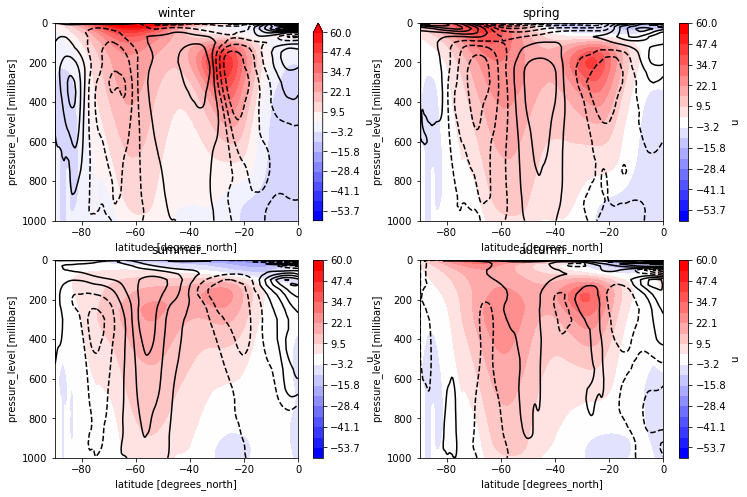

In [98]:
fig,axs = plt.subplots(2,2, figsize=(12,8))
axs = axs.flatten()

for i,s in enumerate([6,9,12,3]):
    
    da = era5_seasonal.sel(time=era5_seasonal.time.dt.month.isin([s]))
    #da = da.reindex(lev=da.lev[::-1])
    
    past = da.sel(time=slice('1979','1986'),longitude=slice(160,200)).mean(['longitude','time']).isel(expver=0)
    present = da.sel(time=slice('2002','2011'),longitude=slice(160,200)).mean(['longitude','time']).isel(expver=0)
    diff = present - past
    
    past.plot.contourf(ax=axs[i],vmin=-60,vmax=60,cmap='bwr',levels=20)
    diff.plot.contour(ax=axs[i],levels=20,vmin=-10,vmax=10,colors='black')#vmin=-7,vmax=7,levels=20)
    axs[i].set_ylim(axs[i].get_ylim()[::-1])
    
    axs[i].set_title(season_a[s])
    
plt.savefig('/nesi/project/niwa00015/queenle/figures/wind/ERA5.png',dpi=300)

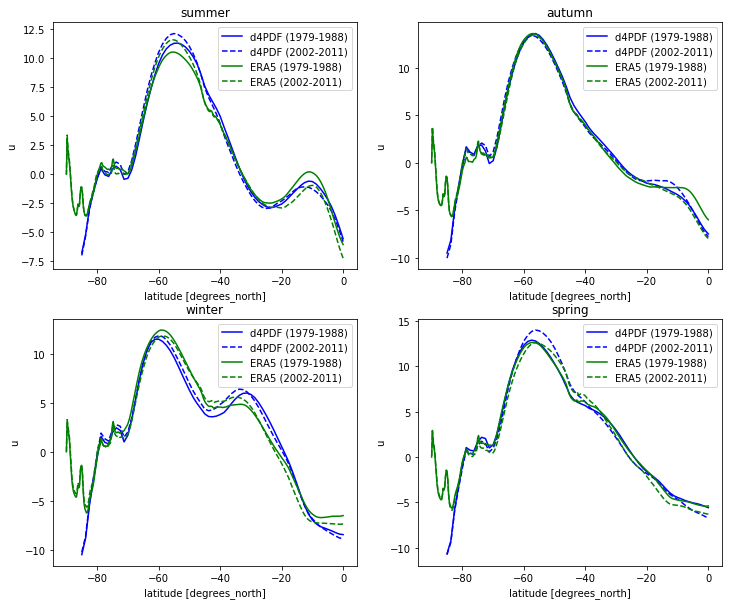

In [101]:
fig,axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.flatten()

season_a = {3:'autumn',6:'winter',9:'spring',12:'summer'}
for i,season in enumerate([12,3,6,9]):
    
    da = da_seasonal.sel(time=da_seasonal.time.dt.month.isin([season]))
    
    past = da.sel(time=slice('1979','1988'),lon=slice(160,200),lat=slice(-90,0),lev=850).mean(['lon','time'])
    past.plot(ax=axs[i],color='blue',linestyle='-', label='d4PDF (1979-1988)')
    
    present = da.sel(time=slice('2002','2011'),lon=slice(160,200),lat=slice(-90,0),lev=850).mean(['lon','time'])
    present.plot(ax=axs[i],color='blue',linestyle='--', label='d4PDF (2002-2011)')
    
    
    era_da = era5_seasonal.sel(time=era5_seasonal.time.dt.month.isin([season]))
    
    past = era_da.sel(time=slice('1979','1988'),longitude=slice(160,200),level=850).mean(['longitude','time'])
    past.isel(expver=0).plot(ax=axs[i],color='green',linestyle='-', label='ERA5 (1979-1988)')
    
    present = era_da.sel(time=slice('2002','2011'),longitude=slice(160,200),level=850).mean(['longitude','time'])
    present.isel(expver=0).plot(ax=axs[i],color='green',linestyle='--', label='ERA5 (2002-2011)')
    
    axs[i].legend()
    axs[i].set_title(season_a[season])
    


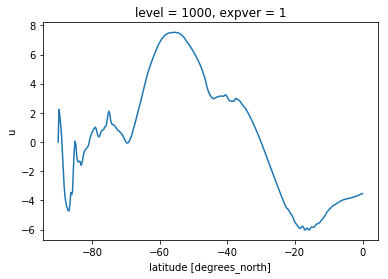

In [80]:
past.isel(expver=0).plot()

In [15]:
da.lat

<xarray.DataArray 'lat' (lat: 145)>
array([-90.  , -88.75, -87.5 , -86.25, -85.  , -83.75, -82.5 , -81.25, -80.  ,
       -78.75, -77.5 , -76.25, -75.  , -73.75, -72.5 , -71.25, -70.  , -68.75,
       -67.5 , -66.25, -65.  , -63.75, -62.5 , -61.25, -60.  , -58.75, -57.5 ,
       -56.25, -55.  , -53.75, -52.5 , -51.25, -50.  , -48.75, -47.5 , -46.25,
       -45.  , -43.75, -42.5 , -41.25, -40.  , -38.75, -37.5 , -36.25, -35.  ,
       -33.75, -32.5 , -31.25, -30.  , -28.75, -27.5 , -26.25, -25.  , -23.75,
       -22.5 , -21.25, -20.  , -18.75, -17.5 , -16.25, -15.  , -13.75, -12.5 ,
       -11.25, -10.  ,  -8.75,  -7.5 ,  -6.25,  -5.  ,  -3.75,  -2.5 ,  -1.25,
         0.  ,   1.25,   2.5 ,   3.75,   5.  ,   6.25,   7.5 ,   8.75,  10.  ,
        11.25,  12.5 ,  13.75,  15.  ,  16.25,  17.5 ,  18.75,  20.  ,  21.25,
        22.5 ,  23.75,  25.  ,  26.25,  27.5 ,  28.75,  30.  ,  31.25,  32.5 ,
        33.75,  35.  ,  36.25,  37.5 ,  38.75,  40.  ,  41.25,  42.5 ,  43.75,
        45.  ,  46.25,  47.5 ,  48.75,  50.  ,  51.25,  52.5 ,  53.75,  55.  ,
        56.25,  57.5 ,  58.75,  60.  ,  61.25,  62.5 ,  63.75,  65.  ,  66.25,
        67.5 ,  68.75,  70.  ,  71.25,  72.5 ,  73.75,  75.  ,  76.25,  77.5 ,
        78.75,  80.  ,  81.25,  82.5 ,  83.75,  85.  ,  86.25,  87.5 ,  88.75,
        90.  ])
Coordinates:
  * lat      (lat) float64 -90.0 -88.75 -87.5 -86.25 ... 86.25 87.5 88.75 90.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y